# Aramex Fuel Price — Exploratory Data Analysis

Target variables:
- `data/95.csv` — 95 octane petrol price
- `data/50ppm.csv` — 50ppm diesel price

All other CSVs in `data/` are treated as candidate feature/indicator series, each following the
project convention: one row per month, columns `date, value, source, notes`.


In [22]:
# --- Imports ---
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import DBD_1

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)

## Data Loading - Petrol

In [26]:
master_petrol_df = DBD_1.load_petrol()
master_petrol_df["Total_Production_Lag1"] = master_petrol_df["Total_Production"].shift(-1)


/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [27]:
master_petrol_df.head()

,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production,Total_Production_Lag1
0,2011-01-01,872.8,453.949,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764,68700.0099
1,2011-02-01,898.8,479.949,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099,67169.5421
2,2011-03-01,941.8,522.949,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421,67351.0479
3,2011-04-01,996.4,552.149,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479,67087.4645
4,2011-05-01,1025.4,581.149,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645,67851.0400


## Data Loading - Diesel

In [28]:
master_diesel_df = DBD_1.load_diesel()
master_diesel_df["Total_Production_Lag1"] = master_diesel_df["Total_Production"].shift(-1)


/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [29]:
master_diesel_df.head()

,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12,Total_Production,Total_Production_Lag1
0,2011-01-01,789.451,477.03,6.905624,0.159159,7.088029,96.523500,1.432121,96.987143,0.932393,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68537.7764,68700.0099
1,2011-02-01,821.451,509.03,7.140163,0.118266,7.115057,101.449655,4.976158,109.406667,4.277731,...,0.247128,NaN,NaN,93.4814,NaN,NaN,NaN,NaN,68700.0099,67169.5421
2,2011-03-01,884.451,572.03,6.967600,0.120730,6.867400,113.560000,3.168441,115.761429,0.556729,...,0.423471,0.247128,NaN,93.1102,93.4814,NaN,NaN,NaN,67169.5421,67351.0479
3,2011-04-01,953.851,616.03,6.805250,0.119489,6.745443,120.723704,4.066770,124.930000,1.233450,...,-0.558572,0.423471,0.247128,94.0788,93.1102,93.4814,NaN,NaN,67351.0479,67087.4645
4,2011-05-01,969.851,632.03,6.828940,0.132094,6.962600,116.875000,5.568645,114.035000,2.422369,...,-0.258231,-0.558572,0.423471,93.7749,94.0788,93.1102,NaN,NaN,67087.4645,67851.0400


## Data overview - Petrol

In [30]:
print("Shape:", master_petrol_df.shape)
print("\nDate range:", master_petrol_df.index.min(), "to", master_petrol_df.index.max())
master_petrol_df.dtypes


Shape: (187, 62)

Date range: 0 to 186


Date                     datetime64[us]
Total_Fuel_Price                float64
BFP                             float64
USDZAR_Mean                     float64
USDZAR_Std                      float64
                              ...      
INDPRO_Lag3                     float64
INDPRO_Lag6                     float64
INDPRO_Lag12                    float64
Total_Production                float64
Total_Production_Lag1           float64
Length: 62, dtype: object

In [19]:
# --- Missing values ---
missing = master_petrol_df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

INDPRO_Lag12                6.417112
BFP_Lag12                   6.417112
GSCPI_Lag12                 6.417112
GPR_Lag12                   6.417112
BFP_Delta_Lag6              3.743316
INDPRO_Lag6                 3.208556
BFP_Lag6                    3.208556
GSCPI_Lag6                  3.208556
BFP_Delta_Lag5              3.208556
GPR_Lag6                    3.208556
BFP_Delta_Lag4              2.673797
BFP_Delta_Lag3              2.139037
Brent_LastWeekStd_Lag3      1.604278
GPR_Lag3                    1.604278
BFP_Lag3                    1.604278
USDZAR_LastWeekMean_Lag3    1.604278
Brent_MonthMean_Lag3        1.604278
USDZAR_Delta_Lag2           1.604278
GSCPI_Lag3                  1.604278
Brent_LastWeekMean_Lag3     1.604278
GECON_Lag3                  1.604278
BFP_Delta_Lag2              1.604278
INDPRO_Lag3                 1.604278
USDZAR_Mean_Lag3            1.604278
Brent_MonthMean_Lag2        1.069519
Brent_LastWeekMean_Lag2     1.069519
Brent_LastWeekStd_Lag2      1.069519
U

In [20]:
# --- Summary statistics ---
master_petrol_df.describe().T

,count,mean,min,25%,50%,75%,max,std
index,187.0,93.0,0.0,46.5,93.0,139.5,186.0,54.126395
Date,187,2018-10-01 02:41:42.673796,2011-01-01 00:00:00,2014-11-16 00:00:00,2018-10-01 00:00:00,2022-08-16 12:00:00,2026-07-01 00:00:00,NaN
Total_Fuel_Price,187.0,1635.493134,872.8,1287.2,1458.7,2137.75,2806.2,466.348957
BFP,187.0,809.028316,274.77,596.87,718.17,984.97,1689.41,284.968657
USDZAR_Mean,187.0,13.866727,6.802743,11.203592,14.343967,16.715267,19.02058,3.483735
...,...,...,...,...,...,...,...,...
INDPRO_Lag2,185.0,99.847008,84.5619,98.7941,100.4309,101.44,104.1004,2.819144
INDPRO_Lag3,184.0,99.83226,84.5619,98.78585,100.389,101.431075,104.1004,2.819671
INDPRO_Lag6,181.0,99.796535,84.5619,98.7611,100.3273,101.3735,104.1004,2.828872
INDPRO_Lag12,175.0,99.74339,84.5619,98.7534,100.2675,101.3345,104.1004,2.86189


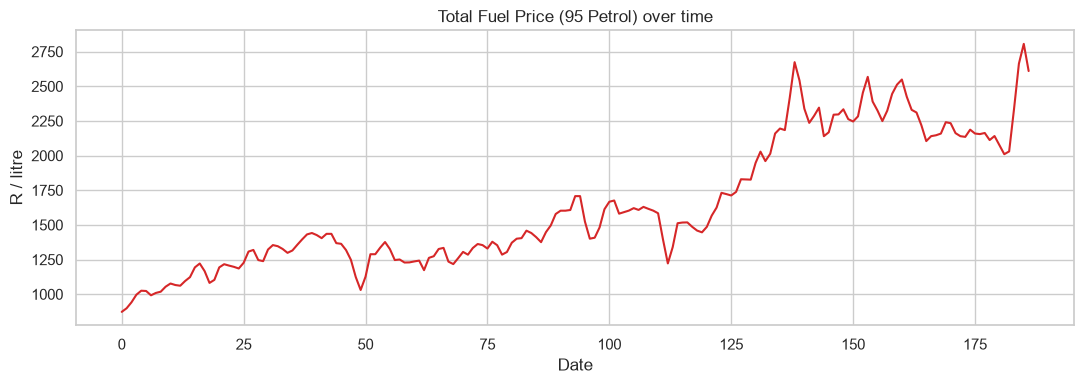

In [14]:
# --- Target variable over time ---
fig, ax = plt.subplots(figsize=(11, 4))
master_petrol_df["Total_Fuel_Price"].plot(ax=ax, color="tab:red")
ax.set_title("Total Fuel Price (95 Petrol) over time")
ax.set_ylabel("R / litre")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

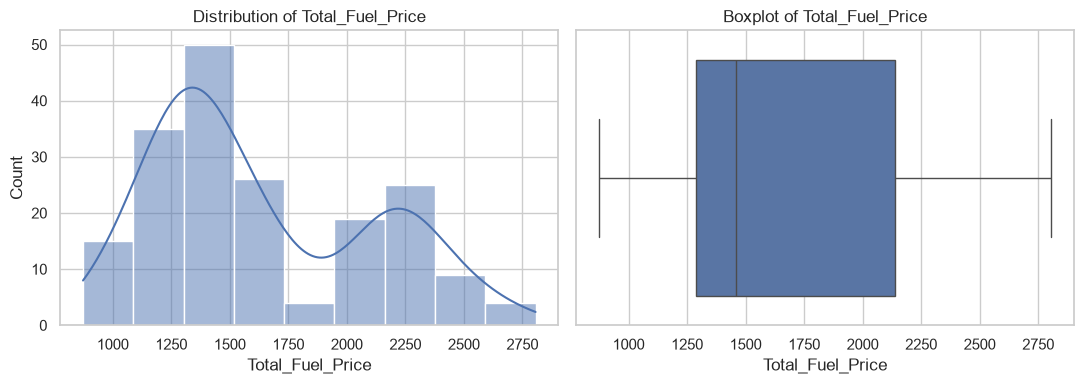

In [15]:
# --- Distribution of target ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(master_petrol_df["Total_Fuel_Price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total_Fuel_Price")

sns.boxplot(x=master_petrol_df["Total_Fuel_Price"], ax=axes[1])
axes[1].set_title("Boxplot of Total_Fuel_Price")
plt.tight_layout()
plt.show()

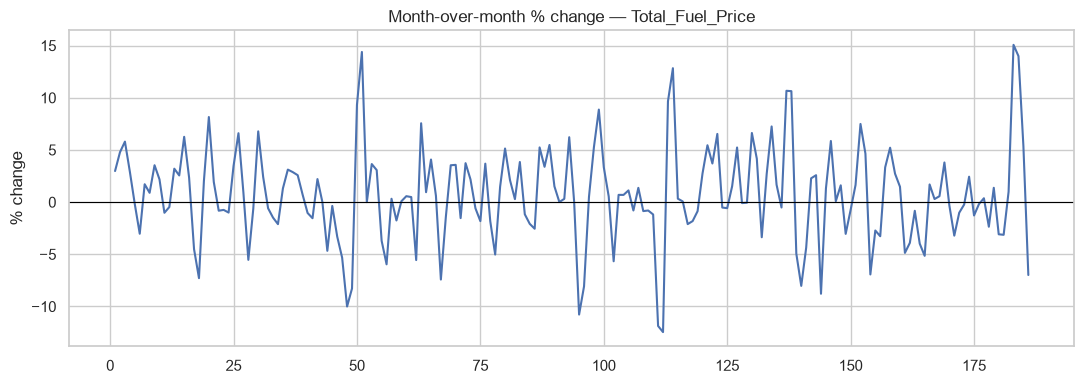

count    186.000000
mean       0.694955
std        4.595505
min      -12.455236
25%       -1.520379
50%        0.519771
75%        3.181599
max       15.071664
Name: Total_Fuel_Price, dtype: float64

In [16]:
# --- Month-over-month % change (volatility) ---
mom_change = master_petrol_df["Total_Fuel_Price"].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4))
mom_change.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-month % change — Total_Fuel_Price")
ax.set_ylabel("% change")
plt.tight_layout()
plt.show()

mom_change.describe()

,Date,Total_Fuel_Price,BFP,USDZAR_Mean,USDZAR_Std,USDZAR_LastWeekMean,Brent_MonthMean,Brent_MonthStd,Brent_LastWeekMean,Brent_LastWeekStd,...,GSCPI_Lag6,GSCPI_Lag12,GECON_Lag1,GECON_Lag2,GECON_Lag3,INDPRO_Lag1,INDPRO_Lag2,INDPRO_Lag3,INDPRO_Lag6,INDPRO_Lag12
0,2026-07-01,2610.2,1307.13,16.404737,0.136279,16.501329,78.709667,7.827145,82.280000,4.017603,...,0.454057,0.026895,1.062294,-0.001306,-0.079102,102.6395,102.5606,102.4196,101.0388,101.8940
1,2026-06-01,2806.2,1609.33,16.410380,0.134329,16.488629,89.264138,12.195101,72.888571,2.490324,...,0.577341,0.096047,-0.001306,-0.079102,-1.291190,102.5606,102.4196,101.6172,101.4941,101.4785
2,2026-05-01,2663.2,1651.37,16.490773,0.136545,16.379743,109.416071,7.794438,100.158333,5.808530,...,-0.122682,0.290260,-0.079102,-1.291190,0.209266,102.4196,101.6172,101.9263,101.0344,100.9655
3,2026-04-01,2336.3,1447.17,16.693410,0.273741,16.561714,116.748214,8.429096,116.922857,5.273420,...,-0.072440,-0.239936,-1.291190,0.209266,0.459790,101.6172,101.9263,101.0388,101.2195,101.1279
4,2026-03-01,2030.3,866.17,16.541643,0.435134,17.059043,94.781333,18.498657,114.968571,8.482695,...,-0.017274,-0.186074,0.209266,0.459790,0.464379,101.9263,101.0388,101.4941,101.6680,101.0404


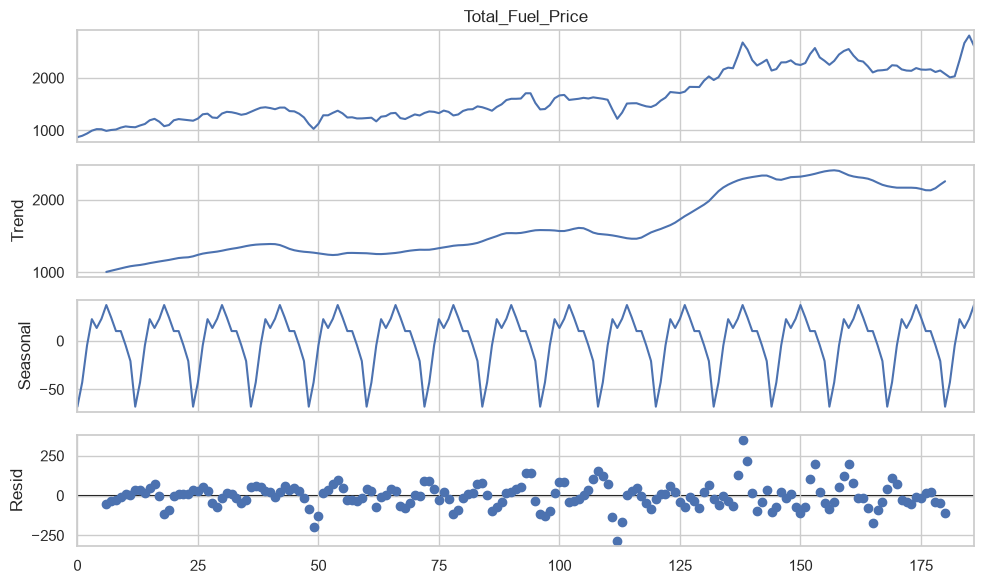

In [17]:
# --- Seasonal decomposition ---
from statsmodels.tsa.seasonal import seasonal_decompose

s = master_petrol_df["Total_Fuel_Price"].dropna()
result = seasonal_decompose(s, model="additive", period=12)
fig = result.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()

In [31]:
# --- Correlation with other columns/features ---
corr = master_petrol_df.corr(numeric_only=True)["Total_Fuel_Price"].sort_values(ascending=False)
corr

Total_Fuel_Price         1.000000
BFP                      0.917838
BFP_Lag1                 0.900064
BFP_Lag2                 0.857644
BFP_Lag3                 0.822322
                           ...   
USDZAR_Delta_Lag1       -0.032166
USDZAR_Delta_Lag2       -0.033552
GECON                   -0.035659
Total_Production_Lag1   -0.772430
Total_Production        -0.777035
Name: Total_Fuel_Price, Length: 61, dtype: float64

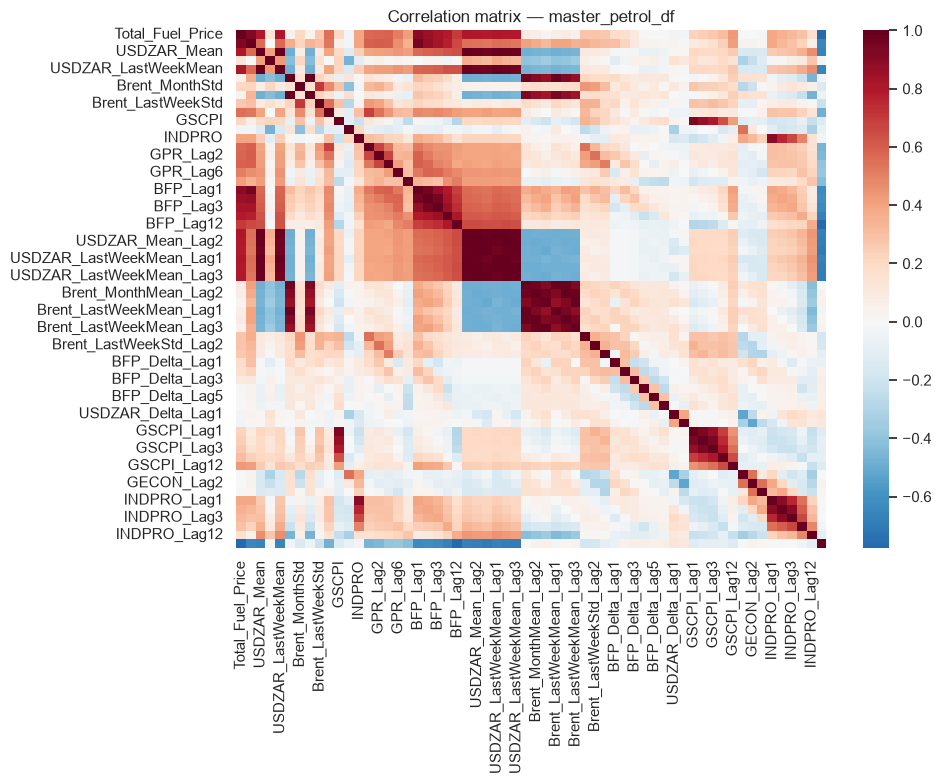

In [18]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(master_petrol_df.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — master_petrol_df")
plt.tight_layout()
plt.show()

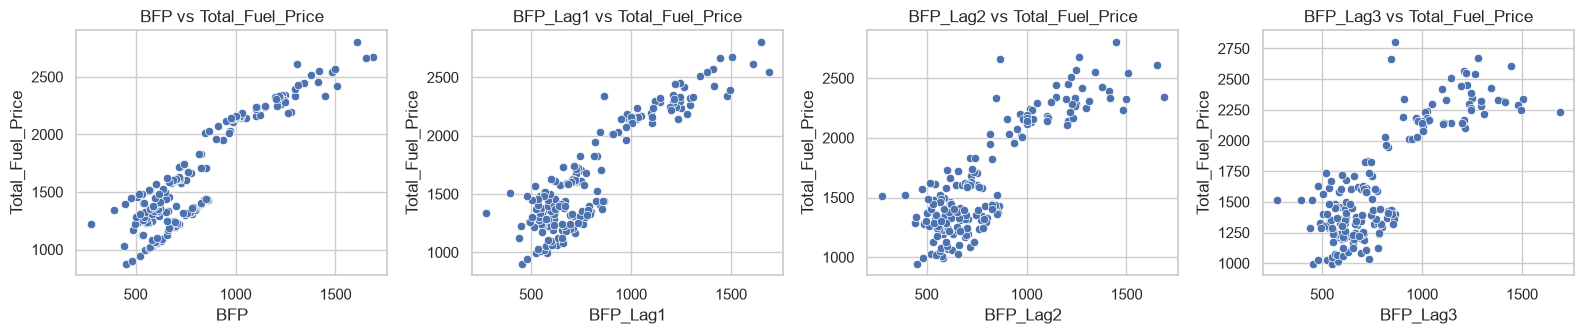

In [19]:
# --- Scatter plots: top correlated features vs target ---
top_feats = corr.drop("Total_Fuel_Price").abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(1, len(top_feats), figsize=(4 * len(top_feats), 3.5))
for ax, feat in zip(axes, top_feats):
    sns.scatterplot(x=master_petrol_df[feat], y=master_petrol_df["Total_Fuel_Price"], ax=ax)
    ax.set_title(f"{feat} vs Total_Fuel_Price")
plt.tight_layout()
plt.show()

## Data Overview - Diesel

In [36]:
print("Shape:", master_diesel_df.shape)
print("\nDate range:", master_diesel_df.index.min(), "to", master_diesel_df.index.max())
master_diesel_df.dtypes

Shape: (187, 60)

Date range: 0 to 186


Date                        datetime64[us]
Total_Fuel_Price                   float64
BFP                                float64
USDZAR_Mean                        float64
USDZAR_Std                         float64
USDZAR_LastWeekMean                float64
Brent_MonthMean                    float64
Brent_MonthStd                     float64
Brent_LastWeekMean                 float64
Brent_LastWeekStd                  float64
GPR                                float64
GSCPI                              float64
GECON                              float64
INDPRO                             float64
GPR_Lag1                           float64
GPR_Lag2                           float64
GPR_Lag3                           float64
GPR_Lag6                           float64
GPR_Lag12                          float64
BFP_Lag1                           float64
BFP_Lag2                           float64
BFP_Lag3                           float64
BFP_Lag6                           float64
BFP_Lag12  

In [37]:
# --- Summary statistics ---
master_diesel_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,187,2018-10-01 02:41:42.673796,2011-01-01 00:00:00,2014-11-16 00:00:00,2018-10-01 00:00:00,2022-08-16 12:00:00,2026-07-01 00:00:00,NaN
Total_Fuel_Price,187.0,1497.996385,789.451,1137.88,1316.82,1884.66,3230.0,476.590955
BFP,187.0,858.985952,367.03,602.03,750.03,1044.03,2606.1,358.049736
USDZAR_Mean,187.0,13.866727,6.802743,11.203592,14.343967,16.715267,19.02058,3.483735
USDZAR_Std,187.0,0.255142,0.070746,0.154492,0.224506,0.298814,1.004549,0.138667
USDZAR_LastWeekMean,187.0,13.884941,6.744229,11.340329,14.309957,16.870229,19.5384,3.472803
Brent_MonthMean,187.0,77.891763,19.534643,59.99,75.251724,102.405517,125.02931,24.599728
Brent_MonthStd,187.0,3.207842,0.729977,1.892888,2.604776,3.694543,18.498657,2.258449
Brent_LastWeekMean,187.0,77.835633,15.92,60.036429,75.064286,101.263571,124.93,24.768364
Brent_LastWeekStd,187.0,1.444915,0.187388,0.8128,1.218807,1.578743,8.482695,1.138006


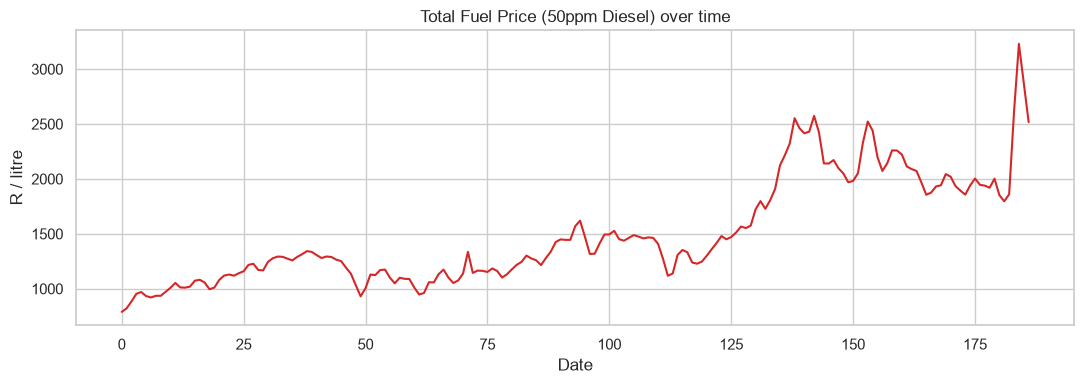

In [44]:
# --- Target variable over time ---
fig, ax = plt.subplots(figsize=(11, 4))
master_diesel_df["Total_Fuel_Price"].plot(ax=ax, color="tab:red")
ax.set_title("Total Fuel Price (50ppm Diesel) over time")
ax.set_ylabel("R / litre")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

In [45]:
diesel_breakdown_df

,Date,BFP,Fuel_Tax,Customs_Excise,Equalization_Fund_Levy,Road_Accident_Fund,Transport_Cost,Petroleum_Products_Levy,Wholesale_Margin,Secondary_Storage,Secondary_Distribution,Retail_Margin,Slate_Levy,Delivery_Cost,DSML,Incremental_Inland_Transport_Recovery_Cost,Total_Fuel_Price
0,2026-07-01,1509.03,416.0,4.0,0.50,225.0,91.1,0.33,99.170,39.0,19.1,0,113.94,0,0,0.0,2517.170
1,2026-06-01,2021.03,219.0,4.0,0.50,225.0,91.1,0.33,99.170,39.0,19.1,0,157.74,0,0,0.0,2875.970
2,2026-05-01,2606.10,23.0,4.0,0.50,225.0,91.1,0.33,99.170,39.0,19.1,0,122.70,0,0,0.0,3230.000
3,2026-04-01,2017.03,116.0,4.0,0.50,225.0,91.1,0.33,99.170,39.0,19.1,0,0.00,0,0,0.0,2611.230
4,2026-03-01,991.03,402.0,4.0,0.50,218.0,87.1,0.33,99.170,39.0,19.1,0,0.00,0,0,0.0,1860.230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,2011-05-01,632.03,162.5,4.0,0.01,80.0,22.9,0.15,53.861,0.0,0.0,0,11.40,0,0,3.0,969.851
183,2011-04-01,616.03,162.5,4.0,0.01,80.0,22.9,0.15,53.861,0.0,0.0,0,11.40,0,0,3.0,953.851
184,2011-03-01,572.03,152.5,4.0,0.01,72.0,15.5,0.15,53.861,0.0,0.0,0,11.40,0,0,3.0,884.451
185,2011-02-01,509.03,152.5,4.0,0.01,72.0,15.5,0.15,53.861,0.0,0.0,0,11.40,0,0,3.0,821.451


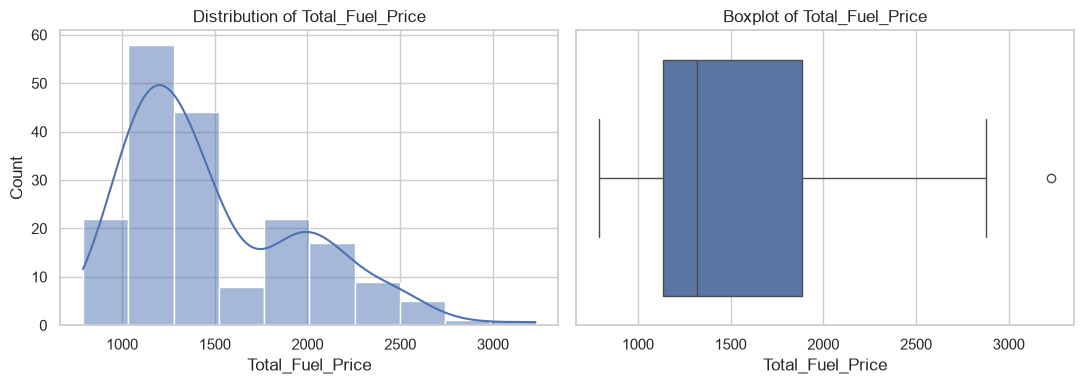

In [46]:
# --- Distribution of target ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(master_diesel_df["Total_Fuel_Price"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Total_Fuel_Price")

sns.boxplot(x=master_diesel_df["Total_Fuel_Price"], ax=axes[1])
axes[1].set_title("Boxplot of Total_Fuel_Price")
plt.tight_layout()
plt.show()

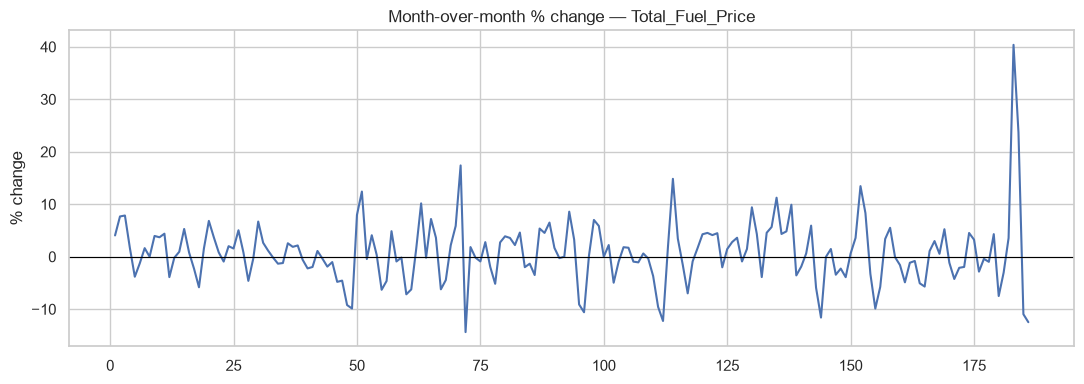

count    186.000000
mean       0.802163
std        6.132306
min      -14.368784
25%       -2.019470
50%        0.613119
75%        3.845528
max       40.371352
Name: Total_Fuel_Price, dtype: float64

In [47]:
# --- Month-over-month % change (volatility) ---
mom_change = master_diesel_df["Total_Fuel_Price"].pct_change() * 100

fig, ax = plt.subplots(figsize=(11, 4))
mom_change.plot(ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-month % change — Total_Fuel_Price")
ax.set_ylabel("% change")
plt.tight_layout()
plt.show()

mom_change.describe()

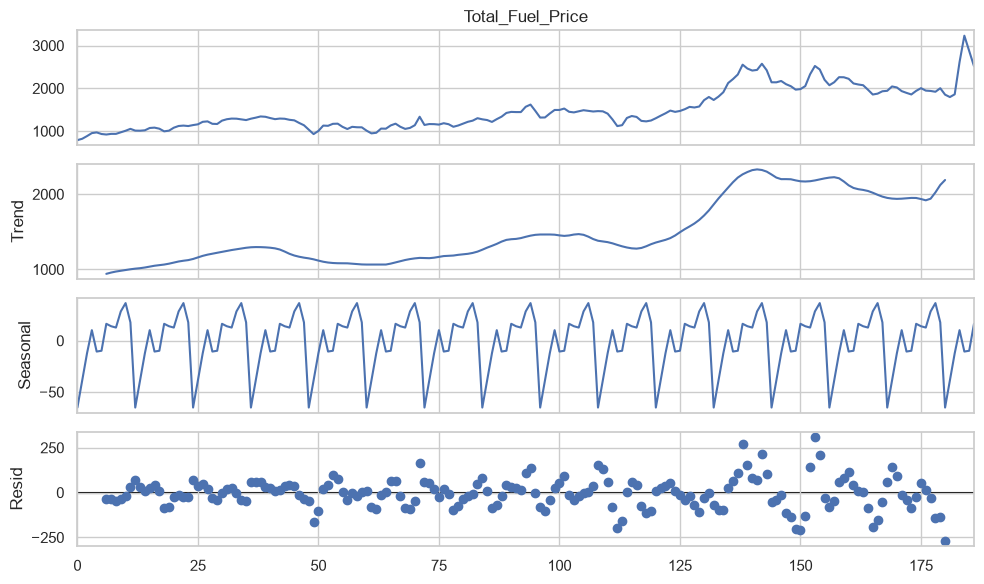

In [48]:
# --- Seasonal decomposition ---
from statsmodels.tsa.seasonal import seasonal_decompose

s = master_diesel_df["Total_Fuel_Price"].dropna()
result = seasonal_decompose(s, model="additive", period=12)
fig = result.plot()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()

In [20]:
# --- Correlation with other columns/features ---
corr = master_diesel_df.corr(numeric_only=True)["Total_Fuel_Price"].sort_values(ascending=False)
corr

Total_Fuel_Price            1.000000
BFP                         0.945658
BFP_Lag1                    0.914272
BFP_Lag2                    0.846553
BFP_Lag3                    0.816426
BFP_Lag6                    0.773146
USDZAR_LastWeekMean         0.740722
USDZAR_Mean                 0.738670
USDZAR_LastWeekMean_Lag1    0.733183
USDZAR_Mean_Lag1            0.729922
USDZAR_LastWeekMean_Lag2    0.722224
USDZAR_Mean_Lag2            0.719154
USDZAR_LastWeekMean_Lag3    0.710997
USDZAR_Mean_Lag3            0.710073
BFP_Lag12                   0.631888
GPR_Lag2                    0.622497
GPR_Lag1                    0.611799
GPR_Lag3                    0.588961
GPR                         0.561995
GPR_Lag6                    0.515307
GSCPI_Lag12                 0.469725
GPR_Lag12                   0.415377
INDPRO                      0.385667
INDPRO_Lag1                 0.381927
Brent_LastWeekStd_Lag2      0.369308
Brent_LastWeekStd_Lag1      0.362429
INDPRO_Lag2                 0.355372
I

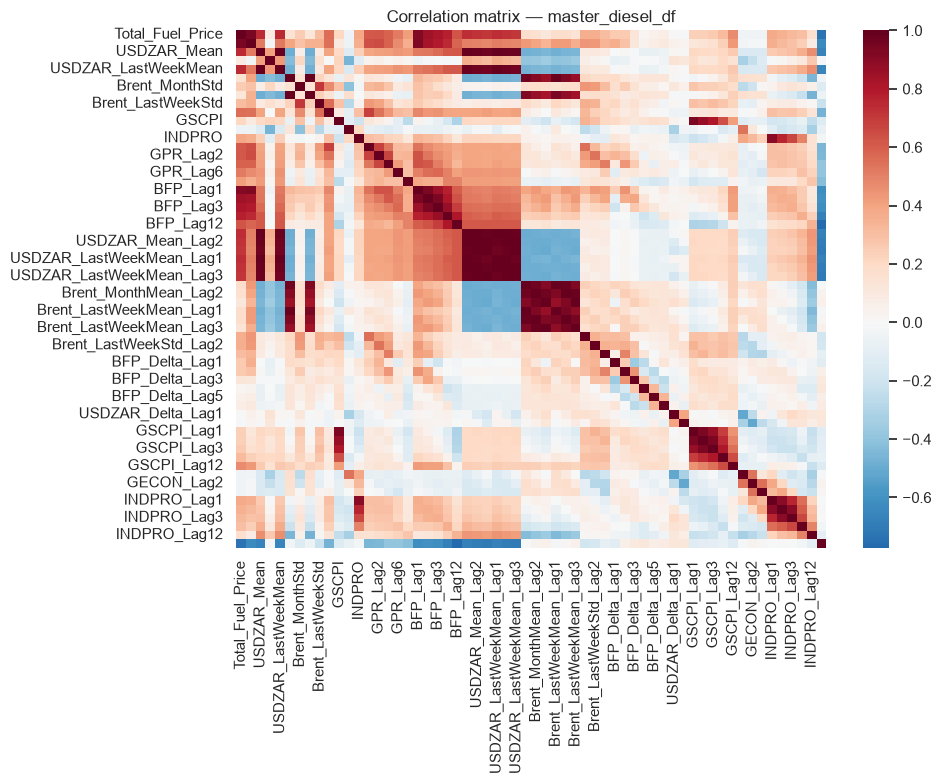

In [21]:
# --- Correlation heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(master_diesel_df.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation matrix — master_diesel_df")
plt.tight_layout()
plt.show()